# 方案二：LunarLander

- **安裝系統依賴**：強制安裝 `swig` (這是 Box2D 必須的)。
- **安裝 Python 套件**：安裝 `box2d-py` 和 `gym[box2d]`。

**執行順序**
1. 執行 **[Cell 1]** 安裝環境。
2. **務必點擊上方選單【執行階段】->【重新啟動工作階段】**。
3. 從 **[Cell 2]** 開始執行到底。

## 註：
前幾次有訓練跟測試出 score 大於零的情況，但未存到權重，只有留下影片，見 `prev_test_land_8_score_136.mp4` 

In [1]:
# [Cell 1] 環境準備
!sudo apt-get update
!sudo apt-get install -y swig

!pip install box2d-py
!pip install gym[box2d]
!pip install pyvirtualdisplay
!pip install torch torchvision numpy matplotlib
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1

print("安裝完成！請點擊 [重新啟動工作階段]")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,233 kB]
Get:10 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,592 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,411 kB]
Hit:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubu

In [1]:
# [Cell 2] 導入與修正
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from pyvirtualdisplay import Display
import cv2
import os

# Numpy fix
try: np.bool8 = np.bool_
except: pass

display = Display(visible=0, size=(1400, 900))
display.start()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Device: cuda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# [Cell 3] 沿用 Mario 的核心架構 (Dueling DQN)
class DuelingNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DuelingNet, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        self.fc_val = nn.Linear(128, 1)
        self.fc_adv = nn.Linear(128, output_dim)

    def forward(self, x):
        feat = self.fc(x)
        val = self.fc_val(feat)
        adv = self.fc_adv(feat)
        return val + (adv - adv.mean(dim=1, keepdim=True))

class Agent:
    def __init__(self, input_dim, output_dim):
        self.policy_net = DuelingNet(input_dim, output_dim).to(device)
        self.target_net = DuelingNet(input_dim, output_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.0005)
        self.memory = deque(maxlen=100000)
        self.epsilon = 1.0
        self.output_dim = output_dim

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.output_dim - 1)
        with torch.no_grad():
            state = torch.tensor([state], dtype=torch.float32).to(device)
            return self.policy_net(state).argmax().item()

    def train(self, batch_size=64):
        if len(self.memory) < batch_size: return
        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(states, dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).to(device)

        curr_Q = self.policy_net(states).gather(1, actions).squeeze(1)
        next_actions = self.policy_net(next_states).argmax(1, keepdim=True)
        next_Q = self.target_net(next_states).gather(1, next_actions).squeeze(1)
        expected_Q = rewards + 0.99 * next_Q * (1 - dones)

        loss = nn.MSELoss()(curr_Q, expected_Q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

Start Training LunarLander with Recording... 


/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment LunarLander-v2 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is depre

Ep 0 | Score: -133.64 | Eps: 0.99


/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment LunarLander-v2 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment LunarLander-v2 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ep 225 | Score: -24.94 | Eps: 0.10


/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment LunarLander-v2 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(


Training finished. Model saved as lunar_final.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


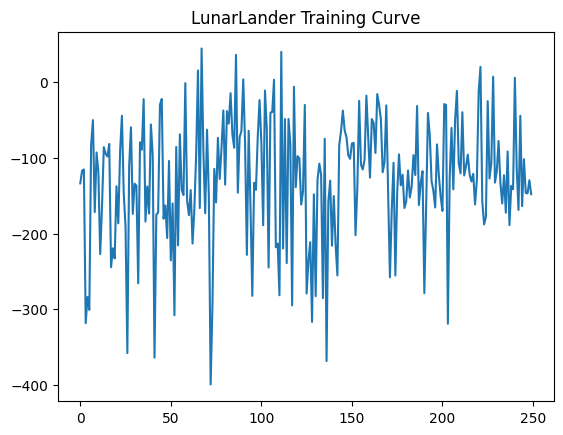

In [3]:
# [Cell 4] 訓練 LunarLander (含錄影功能)
import os

# 設定影片儲存路徑
video_folder = "training_videos"
if not os.path.exists(video_folder):
    os.makedirs(video_folder)

# 建立原始環境
try:
    env_raw = gym.make("LunarLander-v2")
except:
    env_raw = gym.make("LunarLander-v2", new_step_api=False)

# 使用 RecordVideo Wrapper
# episode_trigger 決定何時錄影：這裡設定每 25 回合錄一次 (0, 25, 50...)
env = gym.wrappers.RecordVideo(
    env_raw,
    video_folder,
    episode_trigger=lambda episode_id: episode_id % 25 == 0,
    name_prefix="lunar-train"
)

agent = Agent(env.observation_space.shape[0], env.action_space.n)

scores = []
print("Start Training LunarLander with Recording... ")

# 跑 250 回合
for ep in range(250):
    # 注意：RecordVideo 在 reset 時會自動決定是否啟動錄影
    state = env.reset()
    score = 0
    done = False
    while not done:
        action = agent.act(state)

        # 這裡會自動處理錄影畫面
        res = env.step(action)

        # 萬能解包法處理 gym 版本差異
        if len(res) == 4:
            next_state, reward, done, info = res
        else:
            next_state, reward, terminated, truncated, info = res
            done = terminated or truncated

        agent.memory.append((state, action, reward, next_state, done))
        state = next_state
        score += reward
        agent.train()

    # 衰減探索率
    if agent.epsilon > 0.01:
        agent.epsilon *= 0.99

    if ep % 25 == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())
        print(f"Ep {ep} | Score: {score:.2f} | Eps: {agent.epsilon:.2f}")

    scores.append(score)

    # Removed the score > 200 condition to save the model unconditionally
    if score > 200:
        print(f"Solved at Episode {ep}! Saving model...")
        torch.save(agent.policy_net.state_dict(), "lunar_landed.pth")

# Save the model unconditionally after training
torch.save(agent.policy_net.state_dict(), "lunar_final.pth")
print("Training finished. Model saved as lunar_final.pth")

# 訓練結束關閉環境，確保影片檔案寫入完成
env.close()

plt.plot(scores)
plt.title("LunarLander Training Curve")
plt.show()

In [4]:
# [Cell 5] 錄製登陸影片
print("Recording Landing...")
if not os.path.exists('videos_lunar'): os.makedirs('videos_lunar')

try:
    env = gym.make("LunarLander-v2")
except:
    env = gym.make("LunarLander-v2", new_step_api=False)

agent.epsilon = 0.0 # 測試模式

# 載入 best 權重
try:
    if os.path.exists("lunar_landed.pth"):
        agent.policy_net.load_state_dict(torch.load("lunar_landed.pth"))
        print("Loaded SUCCESS model!")
    else:
        agent.policy_net.load_state_dict(torch.load("lunar_final.pth"))
        print("Loaded FINAL model.")
except: pass

for i in range(1, 11):
    state = env.reset()
    done = False
    frames = []
    total_r = 0
    while not done:
        frames.append(env.render(mode='rgb_array'))
        action = agent.act(state)
        res = env.step(action)
        state, r, done, _ = res if len(res)==4 else (res[0], res[1], res[2] or res[3], res[4])
        total_r += r

    # Save video
    out = cv2.VideoWriter(f'videos_lunar/land_{i}_score_{int(total_r)}.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (600, 400))
    for f in frames: out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
    out.release()
    print(f"Video {i} saved. Score: {total_r}")

print("完成 LunarLander！請下載 videos_lunar 資料夾！")

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


Recording Landing...
Loaded FINAL model.
Video 1 saved. Score: -117.35724934964226
Video 2 saved. Score: -138.20770554547133
Video 3 saved. Score: -134.44665098530612
Video 4 saved. Score: -115.68797728498107
Video 5 saved. Score: -163.66745881035558
Video 6 saved. Score: -69.47074631048882
Video 7 saved. Score: -103.9200166073568
Video 8 saved. Score: -167.82131228752812
Video 9 saved. Score: -9.555789567559428
Video 10 saved. Score: -100.10527995779216
完成 LunarLander！請下載 videos_lunar 資料夾！
